In [1]:
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpu3ruj7ee".


In [2]:
# Скрипт для запуска CUDA программы на T4 в Google Colab

# 1. Проверка доступного GPU
!nvidia-smi
print("\n" + "="*60)

# 2. Установка правильной версии CUDA Toolkit для T4
!apt-get update
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64/cuda-keyring_1.0-1_all.deb
!dpkg -i cuda-keyring_1.0-1_all.deb
!apt-get update
!apt-get -y install cuda-toolkit-11-8

# 3. Настройка переменных окружения
import os
os.environ['PATH'] = '/usr/local/cuda-11.8/bin:' + os.environ['PATH']
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-11.8/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# 4. Проверка установки
!nvcc --version
print("\n" + "="*60)

Thu Jun  4 19:54:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
%%writefile pi_monte_carlo.cu
#include <iostream>
#include <chrono>
#include <cmath>
#include <curand_kernel.h>
#include <cuda_runtime.h>

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            std::cerr << "CUDA error: " << cudaGetErrorString(err) << std::endl; \
            exit(EXIT_FAILURE); \
        } \
    } while(0)

// --- CPU ---
double calc_pi_cpu(int n) {
    unsigned long long hits = 0;
    for (int i = 0; i < n; ++i) {
        double x = static_cast<double>(rand()) / RAND_MAX;
        double y = static_cast<double>(rand()) / RAND_MAX;
        if (x*x + y*y <= 1.0) hits++;
    }
    return 4.0 * hits / n;
}

// --- GPU Setup CURAND ---
__global__ void setup_curand(curandState* states, unsigned long seed, int num_threads) {
    int id = threadIdx.x + blockIdx.x * blockDim.x;
    if (id < num_threads) {
        curand_init(seed, id, 0, &states[id]);
    }
}

// --- GPU Kernel ---
__global__ void monte_carlo_kernel(curandState* states, unsigned int* block_sums,
                                   int n, int points_per_thread, int num_threads) {
    int tid = threadIdx.x + blockIdx.x * blockDim.x;
    if (tid >= num_threads) return;

    curandState localState = states[tid];
    unsigned int local_hits = 0;

    // Grid-stride loop: каждый поток обрабатывает свою порцию точек
    for (int i = 0; i < points_per_thread; ++i) {
        int idx = tid + i * num_threads;
        if (idx >= n) break;

        float x = curand_uniform(&localState);
        float y = curand_uniform(&localState);
        if (x*x + y*y <= 1.0f) local_hits++;
    }
    states[tid] = localState;

    // Блочная редукция в Shared Memory
    __shared__ unsigned int sdata[256];
    sdata[threadIdx.x] = local_hits;
    __syncthreads();

    for (int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (threadIdx.x < s) {
            sdata[threadIdx.x] += sdata[threadIdx.x + s];
        }
        __syncthreads();
    }

    if (threadIdx.x == 0) {
        block_sums[blockIdx.x] = sdata[0];
    }
}

int main(int argc, char* argv[]) {
    if (argc != 2) {
        std::cerr << "Usage: " << argv[0] << " <num_points>" << std::endl;
        return 1;
    }

    int N = std::atoi(argv[1]);
    const int BLOCK_SIZE = 256;
    const int NUM_BLOCKS = 512;
    int num_threads = BLOCK_SIZE * NUM_BLOCKS;
    int points_per_thread = (N + num_threads - 1) / num_threads;

    // --- CPU ---
    srand(42);
    auto t0 = std::chrono::high_resolution_clock::now();
    double cpu_pi = calc_pi_cpu(N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double cpu_ms = std::chrono::duration<double, std::milli>(t1 - t0).count();

    // --- GPU ---
    curandState* d_states;
    unsigned int* d_block_sums;
    unsigned int* h_block_sums = new unsigned int[NUM_BLOCKS];

    CUDA_CHECK(cudaMalloc(&d_states, num_threads * sizeof(curandState)));
    CUDA_CHECK(cudaMalloc(&d_block_sums, NUM_BLOCKS * sizeof(unsigned int)));

    // Инициализация генераторов (вынесена из замера времени, так как выполняется один раз)
    setup_curand<<<NUM_BLOCKS, BLOCK_SIZE>>>(d_states, 12345ULL, num_threads);
    CUDA_CHECK(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    // Замер только вычислительного ядра
    CUDA_CHECK(cudaEventRecord(start));
    monte_carlo_kernel<<<NUM_BLOCKS, BLOCK_SIZE>>>(d_states, d_block_sums, N, points_per_thread, num_threads);
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float gpu_ms = 0;
    CUDA_CHECK(cudaEventElapsedTime(&gpu_ms, start, stop));

    CUDA_CHECK(cudaMemcpy(h_block_sums, d_block_sums, NUM_BLOCKS * sizeof(unsigned int), cudaMemcpyDeviceToHost));

    // Финальное суммирование на CPU (быстро, т.к. массив маленький)
    unsigned long long total_hits = 0;
    for (int i = 0; i < NUM_BLOCKS; ++i) total_hits += h_block_sums[i];
    double gpu_pi = 4.0 * total_hits / N;

    // Очистка
    CUDA_CHECK(cudaFree(d_states));
    CUDA_CHECK(cudaFree(d_block_sums));
    delete[] h_block_sums;
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    // Вывод: N, CPU_ms, GPU_ms, CPU_Pi, GPU_Pi
    printf("%d,%.3f,%.3f,%.6f,%.6f\n", N, cpu_ms, gpu_ms, cpu_pi, gpu_pi);
    return 0;
}

Overwriting pi_monte_carlo.cu


In [30]:
# Компиляция с подключением CURAND
!nvcc -O2 -o pi_monte_carlo pi_monte_carlo.cu -lcurand

# Тест на 100 000 точек
!./pi_monte_carlo 1000000000

1000000000,36615.093,12.222,3.141633,3.141580


Запуск экспериментов...
N=    100000: CPU=11.612ms, GPU= 0.127ms, Speedup=91.43x, GPU_Pi=3.143560
N=   1000000: CPU=68.230ms, GPU= 0.104ms, Speedup=656.06x, GPU_Pi=3.141232
N=  10000000: CPU=353.595ms, GPU= 0.124ms, Speedup=2851.57x, GPU_Pi=3.141898
N= 100000000: CPU=4303.181ms, GPU= 0.866ms, Speedup=4969.03x, GPU_Pi=3.141464
N= 500000000: CPU=17948.083ms, GPU= 6.691ms, Speedup=2682.42x, GPU_Pi=3.141563
N=1000000000: CPU=36153.330ms, GPU= 9.327ms, Speedup=3876.20x, GPU_Pi=3.141580


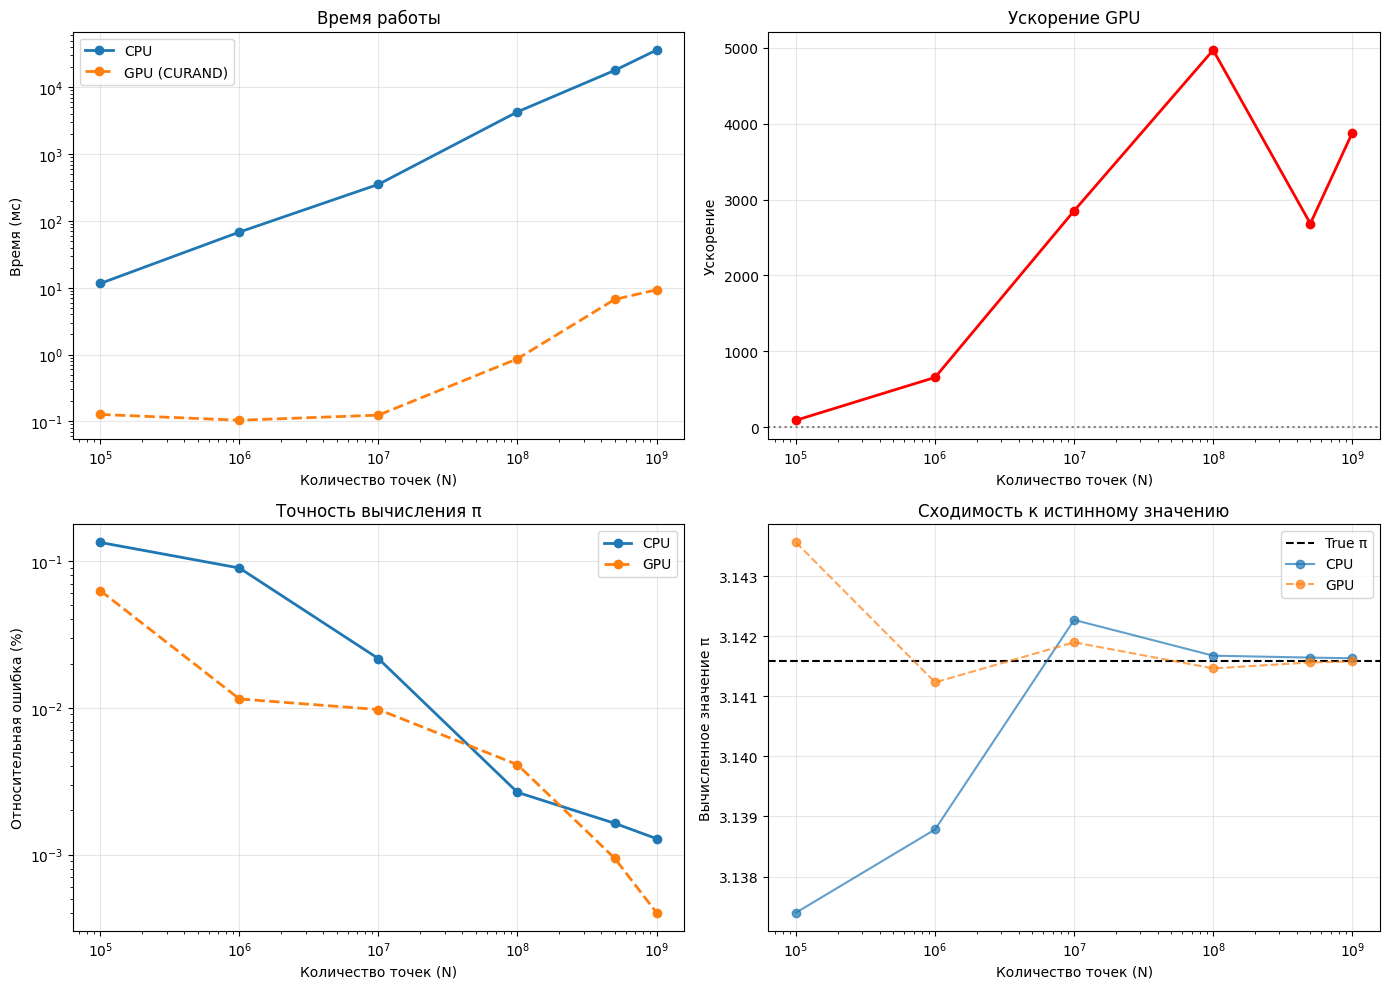


Результаты экспериментов:
         N     CPU (ms)  GPU (ms)     Speedup    CPU π    GPU π
    100000    11.612000  0.127000   91.433071 3.137400 3.143560
   1000000    68.230000  0.104000  656.057692 3.138784 3.141232
  10000000   353.595000  0.124000 2851.572581 3.142271 3.141898
 100000000  4303.181000  0.866000 4969.031178 3.141676 3.141464
 500000000 17948.083000  6.691000 2682.421611 3.141644 3.141563
1000000000 36153.330000  9.327000 3876.201351 3.141633 3.141580


In [33]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sizes = [100000, 1000000, 10000000, 100000000, 500000000, 1000000000]
data = []
TRUE_PI = np.pi

print("Запуск экспериментов...")
for n in sizes:
    out = subprocess.run(['./pi_monte_carlo', str(n)], capture_output=True, text=True)
    if out.returncode == 0:
        parts = out.stdout.strip().split(',')
        if len(parts) == 5:
            n, cpu, gpu, cpu_pi, gpu_pi = parts
            speedup = float(cpu)/float(gpu) if float(gpu) > 0.001 else 0
            data.append({
                'N': int(n),
                'CPU_ms': float(cpu),
                'GPU_ms': float(gpu),
                'Speedup': speedup,
                'CPU_Pi': float(cpu_pi),
                'GPU_Pi': float(gpu_pi)
            })
            print(f"N={n:>10}: CPU={cpu:>6}ms, GPU={gpu:>6}ms, Speedup={speedup:.2f}x, GPU_Pi={gpu_pi}")

df = pd.DataFrame(data)

# === ГРАФИКИ ===
plt.figure(figsize=(14, 10))

# 1. Время выполнения
plt.subplot(2, 2, 1)
plt.plot(df['N'], df['CPU_ms'], 'o-', label='CPU', linewidth=2)
plt.plot(df['N'], df['GPU_ms'], 'o--', label='GPU (CURAND)', linewidth=2)
plt.xlabel('Количество точек (N)')
plt.ylabel('Время (мс)')
plt.title('Время работы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# 2. Ускорение
plt.subplot(2, 2, 2)
plt.plot(df['N'], df['Speedup'], 'o-', color='red', linewidth=2)
plt.axhline(1, color='gray', linestyle=':')
plt.xlabel('Количество точек (N)')
plt.ylabel('Ускорение')
plt.title('Ускорение GPU')
plt.grid(True, alpha=0.3)
plt.xscale('log')

# 3. Точность вычисления Pi
df['CPU_Err'] = np.abs(df['CPU_Pi'] - TRUE_PI) / TRUE_PI * 100
df['GPU_Err'] = np.abs(df['GPU_Pi'] - TRUE_PI) / TRUE_PI * 100

plt.subplot(2, 2, 3)
plt.plot(df['N'], df['CPU_Err'], 'o-', label='CPU', linewidth=2)
plt.plot(df['N'], df['GPU_Err'], 'o--', label='GPU', linewidth=2)
plt.xlabel('Количество точек (N)')
plt.ylabel('Относительная ошибка (%)')
plt.title('Точность вычисления π')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# 4. Разница Pi (визуализация сходимости)
plt.subplot(2, 2, 4)
plt.axhline(TRUE_PI, color='black', linestyle='--', label='True π')
plt.plot(df['N'], df['CPU_Pi'], 'o-', label='CPU', alpha=0.7)
plt.plot(df['N'], df['GPU_Pi'], 'o--', label='GPU', alpha=0.7)
plt.xlabel('Количество точек (N)')
plt.ylabel('Вычисленное значение π')
plt.title('Сходимость к истинному значению')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.show()

# === ТАБЛИЦА ===
print("\nРезультаты экспериментов:")
display_df = df[['N', 'CPU_ms', 'GPU_ms', 'Speedup', 'CPU_Pi', 'GPU_Pi']].copy()
display_df.columns = ['N', 'CPU (ms)', 'GPU (ms)', 'Speedup', 'CPU π', 'GPU π']
print(display_df.to_string(index=False, float_format="%.6f"))

df.to_csv('pi_monte_carlo_results.csv', index=False)